# 04 — Machine Learning: Prediksi Rating
Memprediksi rating pelanggan (1–5) menggunakan fitur order & pengiriman.
Model: Logistic Regression, Random Forest, XGBoost.

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report,
                              confusion_matrix, roc_auc_score,
                              RocCurveDisplay)

# Load data bersih yang sudah ada
df = pd.read_csv('../output/orders_clean.csv',
    parse_dates=['order_purchase_timestamp',
                 'order_delivered_customer_date',
                 'order_estimated_delivery_date'])

reviews = pd.read_csv('../data/olist_order_reviews_dataset.csv')
items   = pd.read_csv('../data/olist_order_items_dataset.csv')

print("Data siap:", df.shape)

Data siap: (110197, 18)


In [8]:
# Gabungkan orders dengan reviews
df_ml = df.merge(
    reviews[['order_id','review_score']], on='order_id', how='inner')

# Gabungkan dengan items untuk hitung jumlah item dan total harga
item_agg = (items.groupby('order_id')
            .agg(
                total_price    = ('price','sum'),
                total_freight  = ('freight_value','sum'),
                item_count     = ('order_item_id','count')
            ).reset_index())

df_ml = df_ml.merge(item_agg, on='order_id', how='left')

# ── Feature engineering ───────────────────────────────────────
# 1. Keterlambatan dalam hari (positif = telat)
df_ml['delay_days'] = (
    df_ml['order_delivered_customer_date'] -
    df_ml['order_estimated_delivery_date']
).dt.days

# 2. Durasi pengiriman aktual dari order sampai terima
df_ml['delivery_days'] = (
    df_ml['order_delivered_customer_date'] -
    df_ml['order_purchase_timestamp']
).dt.days

# 3. Apakah order terlambat? (flag biner)
df_ml['is_late'] = (df_ml['delay_days'] > 0).astype(int)

# 4. Harga per item rata-rata
df_ml['price_per_item'] = df_ml['total_price'] / df_ml['item_count']

# ── Target variabel ───────────────────────────────────────────
df_ml['rating_tinggi'] = (df_ml['review_score'] >= 4).astype(int)

print("Distribusi target:")
print(df_ml['rating_tinggi'].value_counts())
print(f"\nRasio positif: {df_ml['rating_tinggi'].mean():.1%}")

Distribusi target:
rating_tinggi
1    84496
0    25517
Name: count, dtype: int64

Rasio positif: 76.8%


In [9]:
# Pilih fitur yang akan digunakan
features = [
    'delay_days',       # keterlambatan (fitur terkuat)
    'delivery_days',    # durasi pengiriman total
    'is_late',          # flag terlambat atau tidak
    'total_price',      # total belanja
    'total_freight',    # total ongkir
    'item_count',       # jumlah item dalam order
    'price_per_item',   # harga rata-rata per item
]

# Hapus baris dengan missing values di kolom fitur
df_clean = df_ml[features + ['rating_tinggi']].dropna()

print(f"Data sebelum dropna : {len(df_ml):,}")
print(f"Data setelah dropna : {len(df_clean):,}")
print(f"Baris dihapus       : {len(df_ml) - len(df_clean):,}")

X = df_clean[features]
y = df_clean['rating_tinggi']

# Split 80/20 — stratify supaya rasio kelas terjaga di train & test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# Scaling — penting untuk Logistic Regression
scaler  = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"\nTraining set : {len(X_train):,} order")
print(f"Testing set  : {len(X_test):,} order")

Data sebelum dropna : 110,013
Data setelah dropna : 110,005
Baris dihapus       : 8

Training set : 88,004 order
Testing set  : 22,001 order


In [10]:
# ── Model 1: Logistic Regression ─────────────────────────────
lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train_sc, y_train)
y_pred_lr  = lr.predict(X_test_sc)
y_prob_lr  = lr.predict_proba(X_test_sc)[:,1]

# ── Model 2: Random Forest ────────────────────────────────────
rf = RandomForestClassifier(
    n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf  = rf.predict(X_test)
y_prob_rf  = rf.predict_proba(X_test)[:,1]

# ── Tampilkan hasil ───────────────────────────────────────────
for name, y_pred, y_prob in [
    ('Logistic Regression', y_pred_lr, y_prob_lr),
    ('Random Forest',       y_pred_rf, y_prob_rf)
]:
    auc = roc_auc_score(y_test, y_prob)
    print(f"\n=== {name} (AUC: {auc:.3f}) ===")
    print(classification_report(y_test, y_pred,
          target_names=['Rating rendah','Rating tinggi']))


=== Logistic Regression (AUC: 0.707) ===
               precision    recall  f1-score   support

Rating rendah       0.70      0.24      0.36      5103
Rating tinggi       0.81      0.97      0.88     16898

     accuracy                           0.80     22001
    macro avg       0.75      0.60      0.62     22001
 weighted avg       0.78      0.80      0.76     22001


=== Random Forest (AUC: 0.772) ===
               precision    recall  f1-score   support

Rating rendah       0.80      0.48      0.60      5103
Rating tinggi       0.86      0.96      0.91     16898

     accuracy                           0.85     22001
    macro avg       0.83      0.72      0.75     22001
 weighted avg       0.85      0.85      0.84     22001



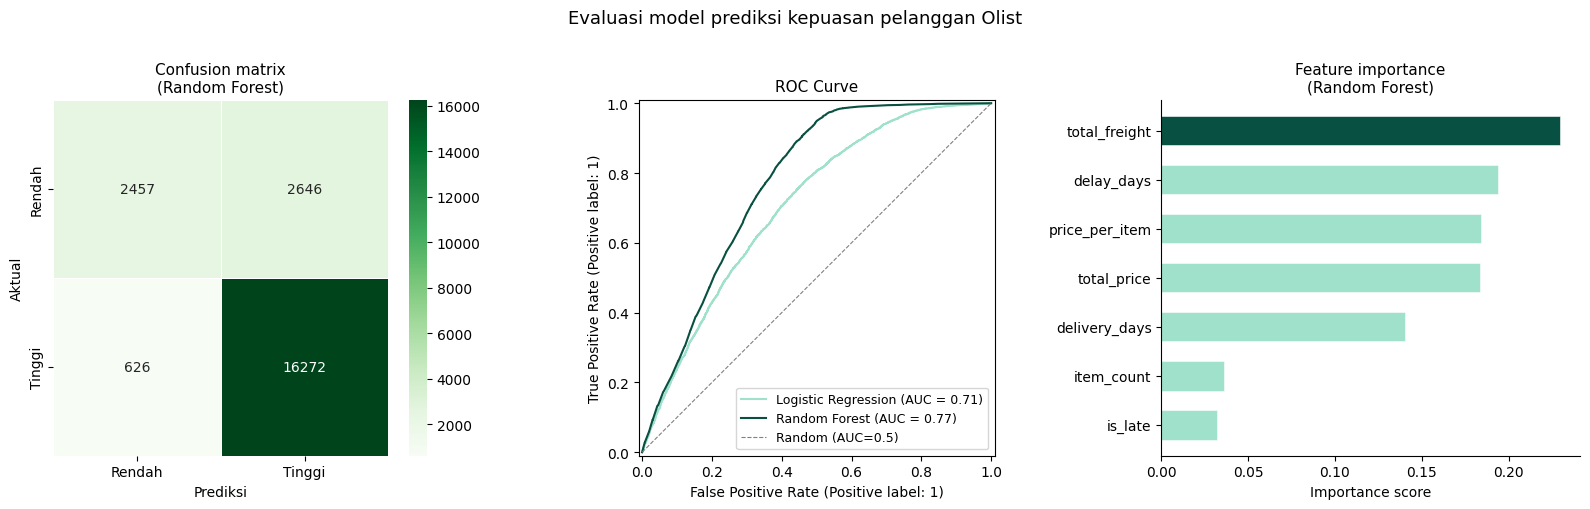

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ── Confusion matrix ──────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            ax=axes[0], linewidths=0.5,
            xticklabels=['Rendah','Tinggi'],
            yticklabels=['Rendah','Tinggi'])
axes[0].set_title('Confusion matrix\n(Random Forest)',
                  fontsize=11, fontweight='500')
axes[0].set_ylabel('Aktual')
axes[0].set_xlabel('Prediksi')

# ── ROC Curve kedua model ─────────────────────────────────────
RocCurveDisplay.from_predictions(
    y_test, y_prob_lr, name='Logistic Regression',
    ax=axes[1], color='#9FE1CB')
RocCurveDisplay.from_predictions(
    y_test, y_prob_rf, name='Random Forest',
    ax=axes[1], color='#085041')
axes[1].plot([0,1],[0,1],'--', color='gray',
             linewidth=0.8, label='Random (AUC=0.5)')
axes[1].set_title('ROC Curve', fontsize=11, fontweight='500')
axes[1].legend(fontsize=9)

# ── Feature importance ────────────────────────────────────────
feat_imp = pd.Series(
    rf.feature_importances_, index=features
).sort_values(ascending=True)

colors = ['#9FE1CB'] * len(feat_imp)
colors[-1] = '#085041'  # highlight fitur terpenting

axes[2].barh(feat_imp.index, feat_imp.values,
             color=colors, height=0.6,
             edgecolor='white', linewidth=0.4)
axes[2].set_title('Feature importance\n(Random Forest)',
                  fontsize=11, fontweight='500')
axes[2].set_xlabel('Importance score')
for sp in ['top','right']: axes[2].spines[sp].set_visible(False)

plt.suptitle('Evaluasi model prediksi kepuasan pelanggan Olist',
             fontsize=13, fontweight='500', y=1.01)
plt.tight_layout()
plt.savefig('../output/ml-evaluasi-rating.png',
            dpi=150, bbox_inches='tight')
plt.show()

In [12]:
## Ringkasan model

# Simpan model untuk digunakan kembali
import joblib
joblib.dump(rf, '../output/model-rating-rf.pkl')
joblib.dump(scaler, '../output/scaler-rating.pkl')
print("Model tersimpan di output/")

Model tersimpan di output/


In [13]:
# Coba prediksi skenario baru
def prediksi_kepuasan(delay_days, delivery_days,
                      total_price, total_freight,
                      item_count):
    is_late = 1 if delay_days > 0 else 0
    price_per_item = total_price / item_count

    fitur = pd.DataFrame([[
        delay_days, delivery_days, is_late,
        total_price, total_freight,
        item_count, price_per_item
    ]], columns=features)

    prob = rf.predict_proba(fitur)[0][1]
    label = "PUAS" if prob >= 0.5 else "TIDAK PUAS"
    print(f"Prediksi  : {label}")
    print(f"Keyakinan : {prob:.1%} kemungkinan puas")

# Skenario 1: order tepat waktu, harga wajar
print("=== Order tepat waktu ===")
prediksi_kepuasan(delay_days=-3, delivery_days=8,
                  total_price=120, total_freight=15,
                  item_count=1)

# Skenario 2: order terlambat 10 hari
print("\n=== Order terlambat 10 hari ===")
prediksi_kepuasan(delay_days=10, delivery_days=25,
                  total_price=120, total_freight=15,
                  item_count=1)

=== Order tepat waktu ===
Prediksi  : PUAS
Keyakinan : 84.0% kemungkinan puas

=== Order terlambat 10 hari ===
Prediksi  : TIDAK PUAS
Keyakinan : 9.0% kemungkinan puas
